# Pesta Data 2026 - Notebook v5
Validasi ganda: Split 80/20 + 5-Fold Cross Validation

**Prinsip yang dipegang:**
- 9 kategori resmi TIDAK digabung/dihapus (sesuai juknis: daftar kelas resmi tetap sama, F1=0 utk kelas yg gak pernah diprediksi)
- Fitur yang dipakai: HANYA fitur robust/general (Tier 1), fitur lookup (ip/domain frequency) di-drop karena terbukti tidak menambah performa & berisiko generalisasi
- Metrik: Macro-F1 (sesuai juknis resmi)

In [1]:
import os
import sys
sys.path.insert(0, '../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

from audit_mislabel import audit_mislabel, apply_relabel, summarize_audit, summarize_diff

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

## 1. Ambil Data

In [2]:
train = pd.read_csv('../../data/raw/training.csv')
test  = pd.read_csv('../../data/raw/predict.csv')

print(f"Dimensi Training : {train.shape}")
print(f"Dimensi Predict  : {test.shape}")
train.head(3)

Dimensi Training : (8400, 10)
Dimensi Predict  : (1500, 10)


,url,brand,discovered,confidence_level,ip,domain,sld,category,registrar,registration_date
0,https://lucah3.***********.my.id/,Telegram,5/1/2024 21:52,100,NaN,***********.my.id,my.id,phishingg,PT Web Media Technology Indonesia,5/14/2026
1,https://dpmptsp.*********.go.id/petapotensi/da...,judi online,8/5/2024 20:41,100,103.162.68.84,*********.go.id,go.id,online gambling,Kementerian Komunikasi dan Informatika,5/11/2009
2,http://klikpad.bkpd.**************.go.id/klikp...,-,6/14/2024 7:05,100,103.18.117.8,**************.go.id,go.id,online gambling,Kementerian Komunikasi dan Informatika,3/13/2008


## 2. Bersihkan Penulisan Category (TRAIN saja)
Cuma normalisasi typo/kapitalisasi. **TIDAK ADA penggabungan kategori** -- semua 9 kelas resmi dipertahankan.

In [3]:
cat_map = {
    'online gamblingg': 'online gambling', 'Online Gambling': 'online gambling',
    'phishingg': 'phishing', 'otherr': 'other', 'Other': 'other',
    'malwaree': 'malware', 'spamm': 'spam', 'Brand': 'brand',
    'FakeShop': 'fakeshop', 'PIIExposure': 'piiexposure', 
}
train['category'] = train['category'].str.strip().replace(cat_map).str.lower().str.strip()

print("=== Distribusi Kategori Setelah Pembersihan (9 kelas, TIDAK digabung) ===")
print(train['category'].value_counts())

=== Distribusi Kategori Setelah Pembersihan (9 kelas, TIDAK digabung) ===
category
online gambling    5447
phishing           2253
other               284
spam                185
malware             179
brand                45
fakeshop              5
violence              1
piiexposure           1
Name: count, dtype: int64


## 3. Visualisasi: Distribusi Kategori (Sebelum Audit Label)

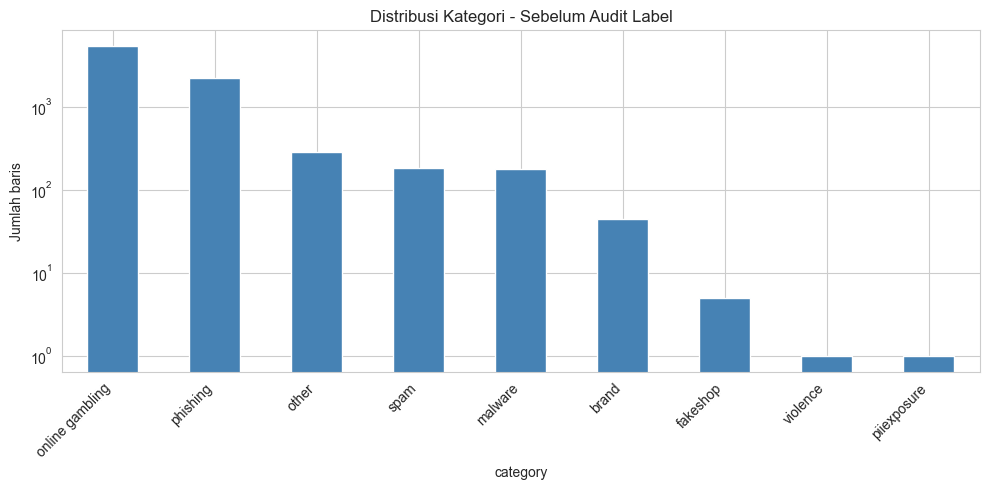

In [4]:
fig, ax = plt.subplots(figsize=(10,5))
train['category'].value_counts().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Distribusi Kategori - Sebelum Audit Label')
ax.set_ylabel('Jumlah baris')
ax.set_yscale('log')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Audit & Perbaiki Category (TRAIN saja, bukti url + ip)
Sesuai juknis: panitia menambahkan noise 3-5% (label salah, duplikasi) ke training. Peserta boleh & didorong memperbaiki label, dengan catatan perubahan yang bisa dijelaskan.

In [5]:
train_audited = audit_mislabel(train)
summarize_audit(train_audited)

=== Distribusi skor kecurigaan ===
suspect_score
11       1
8       24
7        1
6        1
5       34
4       10
3      129
2      134
1      132
0     7934
Name: count, dtype: int64

Skor >=5 (relabel otomatis)      : 61 baris
Skor 3-4 (verifikasi manual)     : 139 baris
Skor 1-2 (biarkan, terlalu lemah): 266 baris


In [6]:
train, diff_table = apply_relabel(train_audited, score_threshold=5)
summarize_diff(diff_table)

os.makedirs('../../data/result/v5', exist_ok=True)
diff_table.to_csv('../../data/result/v5/relabel_diff.csv', index=False)
print("\nCatatan perubahan label tersimpan di data/result/v5/relabel_diff.csv")
print("(disimpan sesuai ketentuan juknis: 'simpan data asli serta catatan perubahan')")

=== Total baris yang benar-benar berubah label: 61 ===

=== Perubahan per pasangan (label lama -> label baru) ===
category_before  category_after 
phishing         online gambling    20
malware          online gambling    14
spam             online gambling    12
other            online gambling     8
online gambling  phishing            6
spam             phishing            1
dtype: int64

Catatan perubahan label tersimpan di data/result/v5/relabel_diff.csv
(disimpan sesuai ketentuan juknis: 'simpan data asli serta catatan perubahan')


## 5. Feature Engineering (Fitur Robust/General saja)
Hanya fitur yang terbukti causal & general (divalidasi EDA + riset eksternal), BUKAN fitur lookup (ip/domain frequency) yang berisiko gagal generalisasi ke data benar-benar baru.

In [7]:
train['discovered'] = pd.to_datetime(train['discovered'], format='%m/%d/%Y %H:%M')
train['registration_date'] = pd.to_datetime(train['registration_date'], format='%m/%d/%Y')
test['discovered'] = pd.to_datetime(test['discovered'], format='%m/%d/%Y %H:%M')
test['registration_date'] = pd.to_datetime(test['registration_date'], format='%m/%d/%Y')

train['domain_age_days'] = (train['discovered'] - train['registration_date']).dt.days
test['domain_age_days'] = (test['discovered'] - test['registration_date']).dt.days

train['domain_age_is_negative'] = (train['domain_age_days'] < 0).astype(int)
test['domain_age_is_negative'] = (test['domain_age_days'] < 0).astype(int)

train['domain_age_days'] = train['domain_age_days'].fillna(train['domain_age_days'].median())
test['domain_age_days'] = test['domain_age_days'].fillna(train['domain_age_days'].median())

In [8]:
train['url_length'] = train['url'].str.len()
test['url_length'] = test['url'].str.len()

In [9]:
for df in [train, test]:
    df['brand_is_missing'] = df['brand'].isna() | (df['brand'].str.strip() == '-')

In [10]:
train = pd.get_dummies(train, columns=['sld'], prefix='sld')
test = pd.get_dummies(test, columns=['sld'], prefix='sld')

train_sld_cols = set(c for c in train.columns if c.startswith('sld_'))
test_sld_cols = set(c for c in test.columns if c.startswith('sld_'))

for col in train_sld_cols - test_sld_cols:
    test[col] = 0
for col in test_sld_cols - train_sld_cols:
    train[col] = 0

## 6. Sanity Check & Simpan Data Bersih

In [11]:
sld_cols = [c for c in train.columns if c.startswith('sld_')]
feature_cols = [
    'domain_age_days', 'domain_age_is_negative',
    'url_length', 'brand_is_missing',
] + sld_cols

print(f"Total fitur dipakai: {len(feature_cols)}")
print("\nMissing value tersisa (train):")
print(train[feature_cols].isna().sum()[train[feature_cols].isna().sum() > 0])
print("\nMissing value tersisa (test):")
print(test[feature_cols].isna().sum()[test[feature_cols].isna().sum() > 0])

train.to_csv('../../data/result/v5/train_final.csv', index=False)
test.to_csv('../../data/result/v5/test_final.csv', index=False)
print("\nTersimpan!")

Total fitur dipakai: 17

Missing value tersisa (train):
Series([], dtype: int64)

Missing value tersisa (test):
Series([], dtype: int64)



Tersimpan!


## 7. VALIDASI METODE 1 -- Split 80/20
Kategori dengan 1 sampel (`violence`, `pii_exposure`) tidak bisa di-stratify -- dipaksa masuk ke bagian training saja, supaya model minimal 'mengenal' pola itu (walau tidak bisa diuji di validation).

In [12]:
X = train[feature_cols]
y = train['category']

counts = y.value_counts()
singleton_categories = counts[counts == 1].index.tolist()
print("Kategori singleton (dipaksa masuk training):", singleton_categories)

mask_singleton = y.isin(singleton_categories)
X_rest, y_rest = X[~mask_singleton], y[~mask_singleton]

X_train, X_val, y_train, y_val = train_test_split(
    X_rest, y_rest, test_size=0.2, stratify=y_rest, random_state=42
)
X_train = pd.concat([X_train, X[mask_singleton]])
y_train = pd.concat([y_train, y[mask_singleton]])

model = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)
pred_val = model.predict(X_val)

print(classification_report(y_val, pred_val, zero_division=0))
print(f"Macro F1 (split 80/20): {f1_score(y_val, pred_val, average='macro', zero_division=0):.4f}")

Kategori singleton (dipaksa masuk training): ['violence', 'piiexposure']
                 precision    recall  f1-score   support

          brand       0.56      0.56      0.56         9
       fakeshop       0.00      0.00      0.00         1
        malware       0.70      0.48      0.57        33
online gambling       0.96      0.98      0.97      1099
          other       0.89      0.87      0.88        55
       phishing       0.97      0.94      0.96       448
           spam       0.71      0.77      0.74        35

       accuracy                           0.95      1680
      macro avg       0.68      0.66      0.67      1680
   weighted avg       0.95      0.95      0.95      1680

Macro F1 (split 80/20): 0.6680


### Visualisasi: Confusion Matrix (Split 80/20)

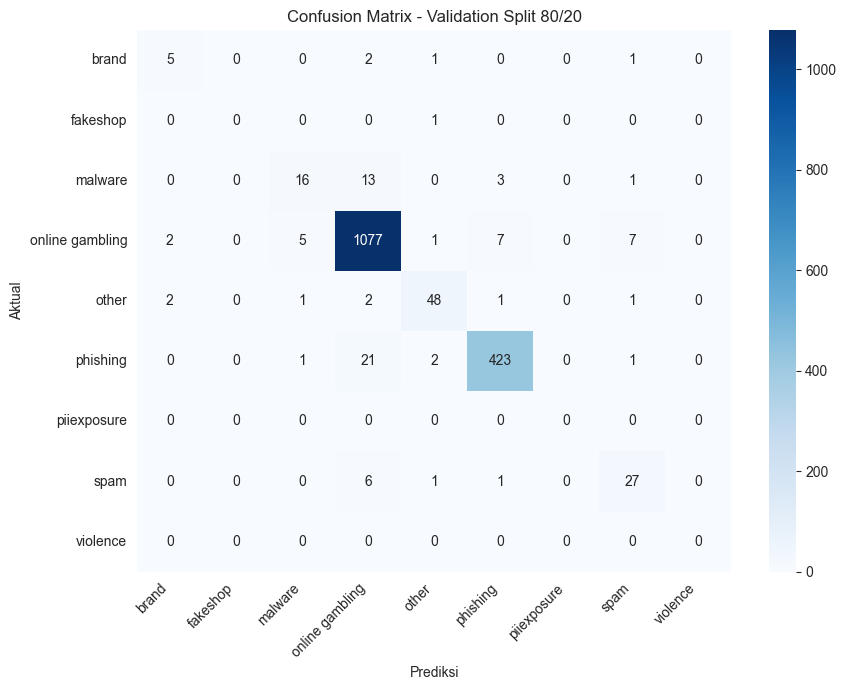

In [13]:
labels = sorted(y.unique())
cm = confusion_matrix(y_val, pred_val, labels=labels)

plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - Validation Split 80/20')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Diagnosis Overfitting: F1 Train vs F1 Validation

In [14]:
f1_train = f1_score(y_train, model.predict(X_train), average='macro', zero_division=0)
f1_val = f1_score(y_val, pred_val, average='macro', zero_division=0)

print(f"Macro F1 - TRAIN      : {f1_train:.4f}")
print(f"Macro F1 - VALIDATION : {f1_val:.4f}")
print(f"Selisih (gap)         : {f1_train - f1_val:.4f}")

if f1_train - f1_val > 0.25:
    print("\n⚠️  Gap besar -> sebagian besar didorong kategori dgn sampel sangat sedikit")
else:
    print("\n✅ Gap wajar")

Macro F1 - TRAIN      : 0.9898
Macro F1 - VALIDATION : 0.6680
Selisih (gap)         : 0.3218

⚠️  Gap besar -> sebagian besar didorong kategori dgn sampel sangat sedikit


## 8. VALIDASI METODE 2 -- 5-Fold Cross Validation
Mengevaluasi SELURUH train.csv (bukan cuma 20%), tiap baris diprediksi oleh model yang tidak pernah melihat baris itu saat training. Kategori dengan sampel <5 tidak bisa mengikuti 5-fold (butuh minimal 5 anggota per kelas) -- dikecualikan HANYA dari evaluasi ini, TETAP dipertahankan penuh di model final.

In [15]:
counts = y.value_counts()
eligible_cv = counts[counts >= 5].index.tolist()
excluded_cv = counts[counts < 5].index.tolist()

print("Kelas ikut 5-Fold CV:", eligible_cv)
print("Kelas TIDAK ikut 5-Fold (sampel <5):", excluded_cv)

mask_eligible = y.isin(eligible_cv)
X_cv, y_cv = X[mask_eligible], y[mask_eligible]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_model = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
y_pred_cv = cross_val_predict(cv_model, X_cv, y_cv, cv=skf)

print("\n=== Classification Report - 5-Fold CV (seluruh data eligible) ===")
print(classification_report(y_cv, y_pred_cv, zero_division=0))
print(f"Macro F1 (5-Fold CV): {f1_score(y_cv, y_pred_cv, average='macro', zero_division=0):.4f}")
print(f"\nCatatan: kelas {excluded_cv} tidak bisa dievaluasi lewat 5-Fold (sampel terlalu sedikit),")
print("tapi tetap dipertahankan penuh sebagai kelas resmi di model final (TIDAK digabung/dihapus).")

Kelas ikut 5-Fold CV: ['online gambling', 'phishing', 'other', 'spam', 'malware', 'brand', 'fakeshop']
Kelas TIDAK ikut 5-Fold (sampel <5): ['violence', 'piiexposure']

=== Classification Report - 5-Fold CV (seluruh data eligible) ===
                 precision    recall  f1-score   support

          brand       0.46      0.27      0.34        45
       fakeshop       0.00      0.00      0.00         5
        malware       0.60      0.44      0.51       165
online gambling       0.96      0.97      0.97      5495
          other       0.81      0.88      0.84       276
       phishing       0.95      0.95      0.95      2240
           spam       0.73      0.74      0.74       172

       accuracy                           0.94      8398
      macro avg       0.65      0.61      0.62      8398
   weighted avg       0.94      0.94      0.94      8398

Macro F1 (5-Fold CV): 0.6208

Catatan: kelas ['violence', 'piiexposure'] tidak bisa dievaluasi lewat 5-Fold (sampel terlalu sedikit),
t

### Visualisasi: Confusion Matrix (5-Fold CV)

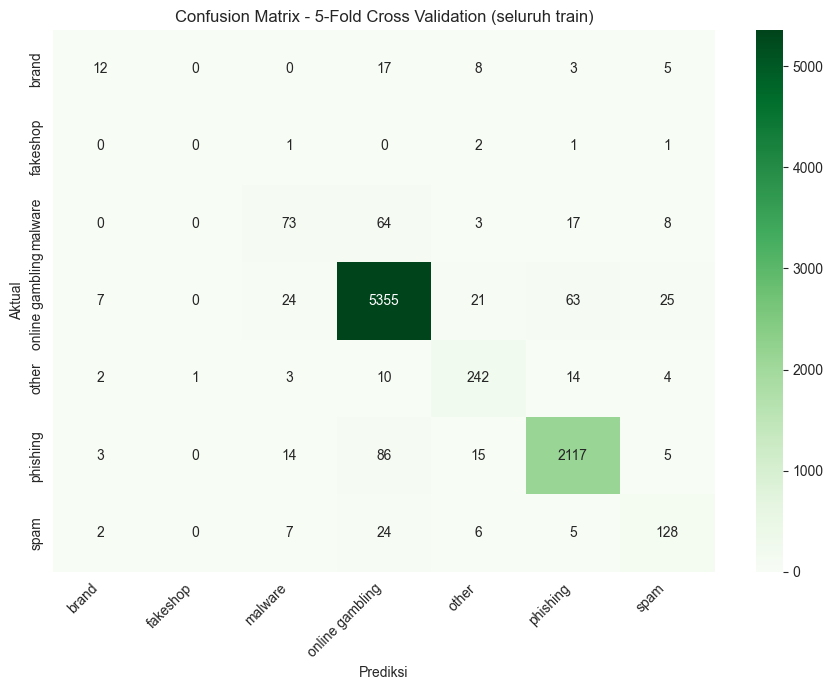

In [16]:
labels_cv = sorted(y_cv.unique())
cm_cv = confusion_matrix(y_cv, y_pred_cv, labels=labels_cv)

plt.figure(figsize=(9,7))
sns.heatmap(cm_cv, annot=True, fmt='d', cmap='Greens', xticklabels=labels_cv, yticklabels=labels_cv)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - 5-Fold Cross Validation (seluruh train)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 9. Feature Importance (Validasi Akhir Fitur)

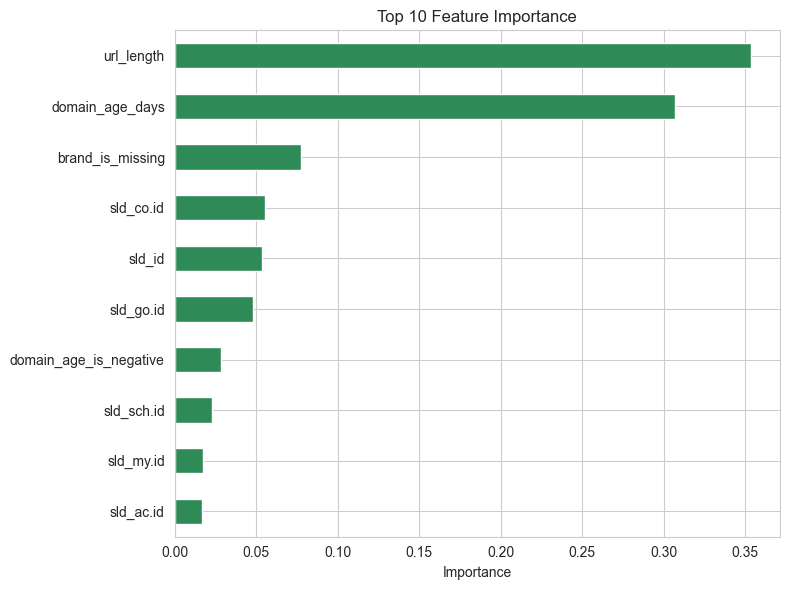

url_length                0.353670
domain_age_days           0.306862
brand_is_missing          0.077296
sld_co.id                 0.055386
sld_id                    0.053886
sld_go.id                 0.048353
domain_age_is_negative    0.028412
sld_sch.id                0.022688
sld_my.id                 0.017515
sld_ac.id                 0.017047
sld_net.id                0.005731
sld_biz.id                0.005675
sld_or.id                 0.003480
sld_ponpes.id             0.001915
sld_desa.id               0.001060
sld_web.id                0.000747
sld_mil.id                0.000278
dtype: float64


In [17]:
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8,6))
importance.head(10).plot(kind='barh', color='seagreen')
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(importance)

## 10. Retrain Pakai SELURUH Train, Prediksi ke Predict.csv, Simpan Submission
**PENTING**: karena hanya dijatah maksimal 3x submission (sesuai juknis), pastikan hasil validasi di atas (split 80/20 dan 5-Fold CV) sudah dianggap memuaskan sebelum submit.

In [18]:
final_model = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
final_model.fit(X, y)

X_test = test[feature_cols]
predictions = final_model.predict(X_test)

print("Distribusi hasil prediksi ke predict.csv:")
print(pd.Series(predictions).value_counts())

Distribusi hasil prediksi ke predict.csv:
online gambling    996
phishing           401
other               45
spam                31
malware             22
brand                4
fakeshop             1
Name: count, dtype: int64


In [19]:
submission = pd.read_csv('../../data/raw/submission-template.csv')
submission['category'] = predictions
submission.to_csv('../../data/result/v5/submission.csv', index=False)
print("Submission tersimpan di data/result/v5/submission.csv")
submission.head()

Submission tersimpan di data/result/v5/submission.csv


,id,category
0,PEDAS-bf8bc60352a3,phishing
1,PEDAS-7dd13e6859b0,online gambling
2,PEDAS-0fe0d926e0d2,phishing
3,PEDAS-37db191c480d,phishing
4,PEDAS-2d06b168bfcc,online gambling
